# Notebook 03: Model Preparation

## Objective

The objective of this notebook is to prepare the processed manufacturing dataset for machine learning.

The following tasks will be performed:

- Load processed dataset
- Separate features and target
- Split dataset into training and testing sets
- Scale numerical features
- Analyze class imbalance
- Save preprocessing artifacts for future use

In [2]:
# ============================================================
# Smart Manufacturing Data Analytics and Predictive Maintenance
# Notebook 03: Model Preparation
# Author: Opurva Saini
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

In [3]:
df = pd.read_csv("../dataset/ai4i2020_processed.csv")

print("Processed dataset loaded successfully!")

Processed dataset loaded successfully!


In [4]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature Difference,Mechanical Power,Wear Rate,Thermal Stress
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000,449.40
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.002131,486.15
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.003338,513.76
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.004885,410.80
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.006392,420.00


In [5]:
df.shape

(10000, 16)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int64  
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   TWF                      10000 non-null  int64  
 8   HDF                      10000 non-null  int64  
 9   PWF                      10000 non-null  int64  
 10  OSF                      10000 non-null  int64  
 11  RNF                      10000 non-null  int64  
 12  Temperature Difference   10000 non-null  float64
 13  Mechanical Power         10000 non-null  float64
 14  Wear Rate                10000 non

### Observation

The processed dataset contains cleaned and engineered features.

It is now ready to be converted into machine learning input data.

In [7]:
X = df.drop(columns=["Machine failure"])

y = df["Machine failure"]

In [8]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (10000, 15)
Target Shape : (10000,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (8000, 15)
Testing Samples : (2000, 15)


### Why Train-Test Split?

Training data is used to teach the machine learning model.

Testing data is kept unseen and is used only for evaluating model performance.

Using stratified sampling preserves the proportion of failure and non-failure cases in both datasets.

In [11]:
scaler = StandardScaler()

In [12]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [13]:
print(X_train_scaled[:5])

[[ 1.34125703  0.99891359  0.60428162 -0.46060741  0.71830476 -0.84399726
  -0.06723349 -0.10424403 -0.10176517 -0.10176517 -0.04334192 -1.10084184
   0.85238725 -0.79134695  0.18387128]
 [ 1.34125703 -1.50519408 -1.15325984 -0.77557391  0.63845583  0.38226308
  -0.06723349 -0.10424403 -0.10176517 -0.10176517 23.07234997  1.29965826
   0.48036335  0.55451289  1.14645266]
 [ 1.34125703  0.49809206  1.07746586 -1.00765448  0.5586069   0.46086951
  -0.06723349 -0.10424403 -0.10176517 -0.10176517 -0.04334192  0.5995124
   0.18404108  0.70974245  0.76821654]
 [-0.33322116 -0.55363316 -0.13929361 -0.70926517  1.62658635 -0.37235867
  -0.06723349 -0.10424403 -0.10176517 -0.10176517 -0.04334192  0.89957491
   1.89886071 -0.26385504  1.97153561]
 [-0.33322116 -1.45511192 -1.01806434  1.07001923 -1.12820177 -0.90688241
  -0.06723349 -0.10424403 -0.10176517 -0.10176517 -0.04334192  1.3996791
  -1.00168744 -0.98491625 -0.67399336]]


### Why Scaling?

Industrial sensor values have different units.

For example:

- Temperature is measured in Kelvin.
- Torque is measured in Newton-meters.
- Rotational speed is measured in RPM.

Scaling places all numerical features on a comparable scale, improving the performance of many machine learning algorithms.

In [14]:
joblib.dump(
    X.columns.tolist(),
    "../models/preprocessing/feature_names.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!


In [15]:
y.value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [16]:
(y.value_counts(normalize=True) * 100).round(2)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

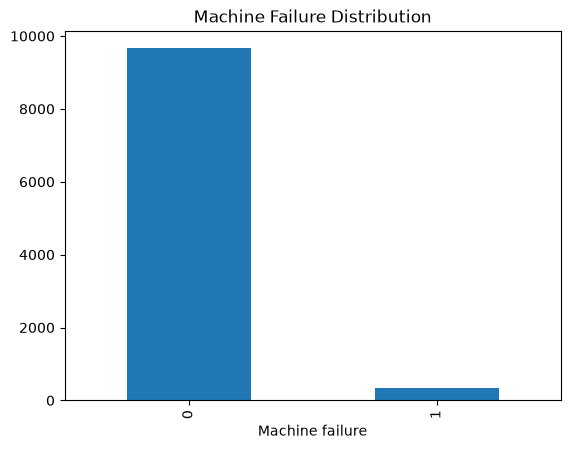

In [17]:
import matplotlib.pyplot as plt

y.value_counts().plot(
    kind="bar",
    title="Machine Failure Distribution"
)

plt.show()

### Observation

Machine failures are significantly fewer than normal operating conditions.

This indicates that the dataset is imbalanced, which is common in predictive maintenance applications because machines usually operate normally for most of their lifespan.

In [18]:
failure_percentage = y.mean() * 100

print(f"Failure Percentage : {failure_percentage:.2f}%")

Failure Percentage : 3.39%


### SMOTE Decision

The dataset is imbalanced.

However, baseline models will first be trained using the original data.

If necessary, SMOTE will be introduced later to compare its impact on prediction performance.

In [19]:
import os

os.makedirs("../models/preprocessing", exist_ok=True)

In [20]:
joblib.dump(
    scaler,
    "../models/preprocessing/scaler.pkl"
)

['../models/preprocessing/scaler.pkl']

In [21]:
joblib.dump(
    X_train_scaled,
    "../models/preprocessing/X_train.pkl"
)

joblib.dump(
    X_test_scaled,
    "../models/preprocessing/X_test.pkl"
)

joblib.dump(
    y_train,
    "../models/preprocessing/y_train.pkl"
)

joblib.dump(
    y_test,
    "../models/preprocessing/y_test.pkl"
)

['../models/preprocessing/y_test.pkl']

In [22]:
print("Preprocessing artifacts saved successfully!")

Preprocessing artifacts saved successfully!


# Notebook Summary

✔ Loaded processed manufacturing dataset

✔ Defined feature matrix and target variable

✔ Performed stratified train-test split

✔ Standardized numerical features

✔ Examined class imbalance

✔ Saved preprocessing artifacts for future notebooks